# HKS → Fate Presence/Absence Classification — Debug Notebook

**Purpose**: Verify that the DiffusionNet encoder can learn meaningful
organoid-level representations under a simple classification objective before
returning to the full VAE.

**Task**: Given per-vertex HKS features on an organoid mesh, predict
**yes/no** whether each cell-fate type is present anywhere on the organoid
surface (i.e., at least one vertex with nonzero fate signal).

**Fates**: The target is binary: 1 = fate present on this organoid, 0 = fate absent.

**Key training decisions**:
- **BCEWithLogitsLoss**: numerically stable binary cross-entropy applied
  directly to raw logits (no sigmoid in the model forward pass).
- **Grad clip=1.0**: Prevents large gradient spikes in early training.
- **Cosine LR schedule**: Decays lr over the training run.

**Diagnostic logic**:
- BCE loss < log(2) ≈ 0.693 → learning better than random guessing
- Accuracy > majority-class baseline → learning the classification signal
- If loss stays near log(2) here → encoder architecture is broken


## 1. Imports & configuration

In [1]:
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
for p in [os.getcwd(), os.path.join(os.getcwd(), '..', '..'), ROOT]:
    if p not in sys.path:
        sys.path.insert(0, p)

from dataset import FateCoverageDataset, compute_coverage
from model import FateCoverageNet

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device: {device}")


Device: mps


In [2]:
# ---- Configuration ----
DATA_PATH    = '../../../Data/small_meshes'
OP_CACHE_DIR = '../../op_cache'
K_EIG        = 128

# Fates to predict (binary: present/absent on each organoid)
FATE_NAMES   = ['lgr', 'sero', 'lyz']

# Model
C_WIDTH      = 32
N_BLOCK      = 4
MLP_HIDDEN   = 16
DROPOUT      = False

# Training
LR           = 1e-3
GRAD_CLIP    = 1.0     # max gradient norm; prevents early-training instability
N_STEPS      = 300
LOG_EVERY    = 30
SAMPLE_IDX   = 5


## 2. Dataset: label statistics


In [3]:
dataset = FateCoverageDataset(
    data_path=DATA_PATH,
    k_eig=K_EIG,
    op_cache_dir=OP_CACHE_DIR,
    fate_names=FATE_NAMES,
)
print(f'Dataset size: {len(dataset)}')
print(f'n_hks: {dataset.n_hks}')

HKS features: 16 (will be clip+z-score normalised)
Fate targets: 3 (lgr, sero, lyz)
FateCoverageDataset: 310 organoids loaded.
Dataset size: 310
n_hks: 16


/Users/yuli/Documents/Code/SphericalHarmonics/DiffusionML/experiments/hks_fate_coverage/../../diffusion_net/utils.py:55: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:656.)
  return torch.sparse.FloatTensor(torch.LongTensor(indices), torch.FloatTensor(values), torch.Size(shape)).coalesce()


Label statistics across 310 organoids:
  Fate         Present    Absent   %Present
  lgr              191       119      61.6%
  sero             155       155      50.0%
  lyz              209       101      67.4%


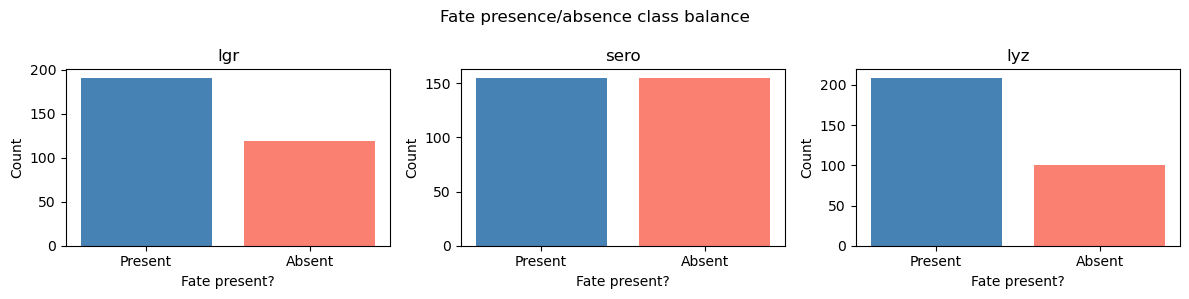

In [4]:
# Collect binary presence labels across all organoids
all_labels = []
all_hks = []
for idx in range(len(dataset)):
    labs = dataset[idx]['coverage']  # binary {0, 1}
    hks  = dataset[idx]['hks']
    all_labels.append(labs)
    all_hks.append(hks)
all_labels = np.array(all_labels)  # (N, n_fates) binary

print(f'Label statistics across {len(dataset)} organoids:')
print(f"  {'Fate':<10} {'Present':>9} {'Absent':>9} {'%Present':>10}")
for i, fn in enumerate(FATE_NAMES):
    n_pos = int(all_labels[:, i].sum())
    n_neg = len(dataset) - n_pos
    pct   = 100.0 * n_pos / len(dataset)
    print(f"  {fn:<10} {n_pos:>9d} {n_neg:>9d} {pct:>9.1f}%")

# Bar chart of class balance
fig, axes = plt.subplots(1, len(FATE_NAMES), figsize=(4*len(FATE_NAMES), 3))
if len(FATE_NAMES) == 1:
    axes = [axes]
for ax, fn, i in zip(axes, FATE_NAMES, range(len(FATE_NAMES))):
    n_pos = int(all_labels[:, i].sum())
    n_neg = len(dataset) - n_pos
    ax.bar(['Present', 'Absent'], [n_pos, n_neg], color=['steelblue', 'salmon'])
    ax.set_title(f'{fn}')
    ax.set_ylabel('Count')
    ax.set_xlabel('Fate present?')
plt.suptitle('Fate presence/absence class balance')
plt.tight_layout()
plt.show()


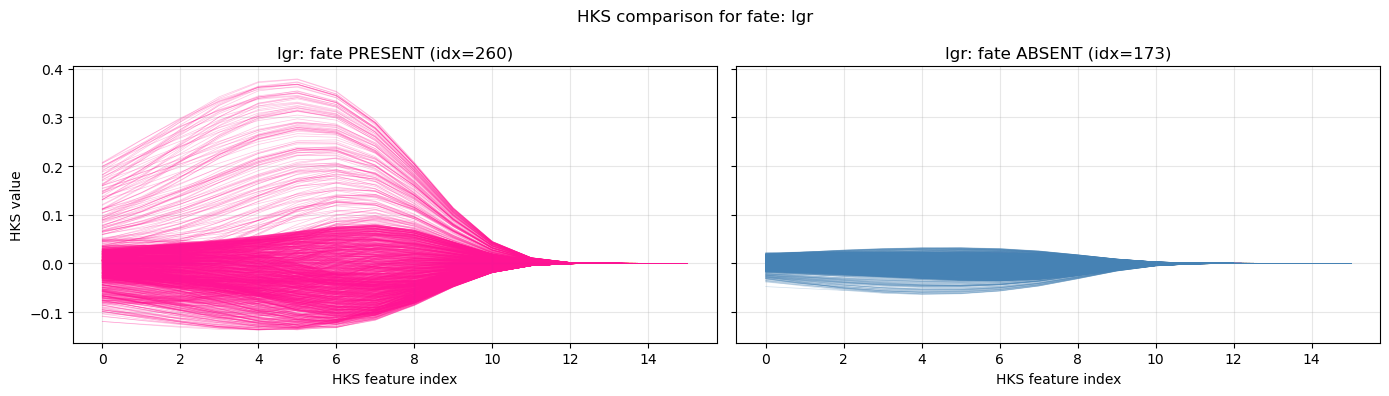

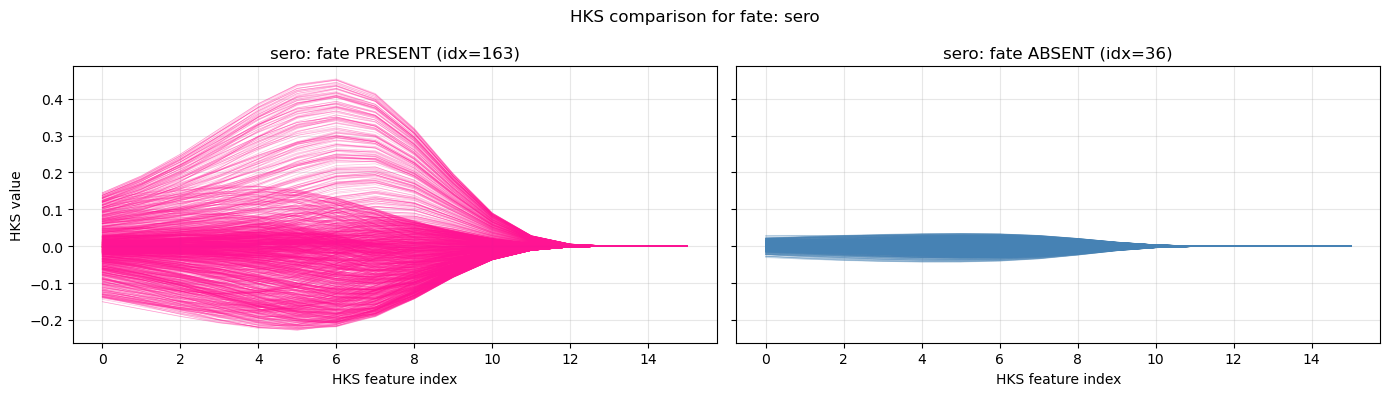

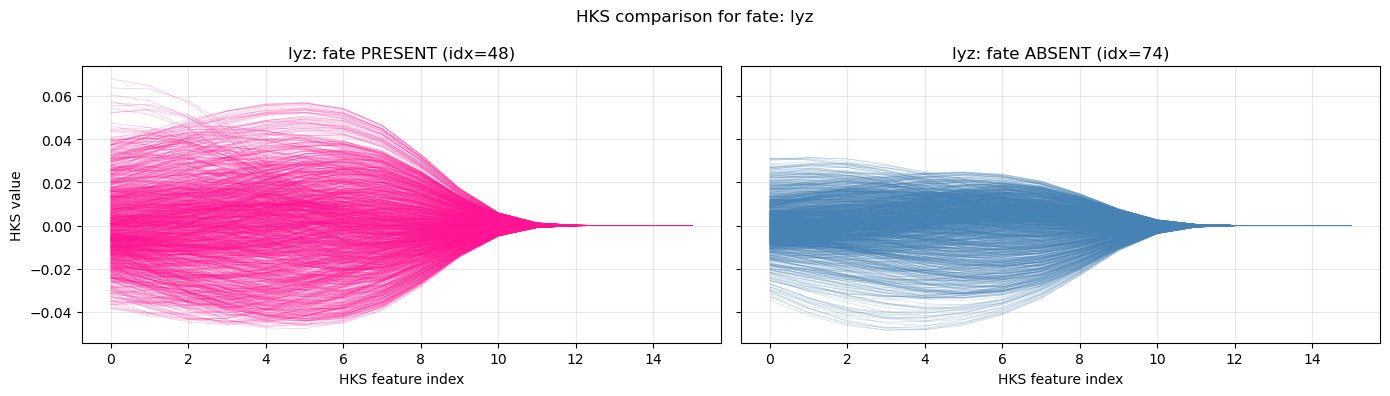

In [5]:
for fate in FATE_NAMES:
    fate_idx = FATE_NAMES.index(fate)
    has_fate = all_labels[:, fate_idx] > 0
    no_fate  = ~has_fate

    if not has_fate.any() or not no_fate.any():
        print(f'Skipping {fate}: missing positive or negative samples.')
        continue

    idx_has = np.random.choice(np.where(has_fate)[0])
    idx_no  = np.random.choice(np.where(no_fate)[0])

    hks_has = all_hks[idx_has].cpu().numpy() if torch.is_tensor(all_hks[idx_has]) else all_hks[idx_has]
    hks_no  = all_hks[idx_no].cpu().numpy()  if torch.is_tensor(all_hks[idx_no])  else all_hks[idx_no]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    axes[0].plot(hks_has.T, linewidth=0.5, color='deeppink', alpha=0.25)
    axes[0].set_title(f"{fate}: fate PRESENT (idx={idx_has})")
    axes[0].set_xlabel('HKS feature index')
    axes[0].set_ylabel('HKS value')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(hks_no.T, linewidth=0.5, color='steelblue', alpha=0.25)
    axes[1].set_title(f"{fate}: fate ABSENT (idx={idx_no})")
    axes[1].set_xlabel('HKS feature index')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'HKS comparison for fate: {fate}')
    plt.tight_layout()
    plt.show()


## 3. Model construction

In [6]:
n_hks = dataset.n_hks
n_fates = len(FATE_NAMES)

model = FateCoverageNet(
    C_in=n_hks,
    n_fates=n_fates,
    C_width=C_WIDTH,
    N_block=N_BLOCK,
    mlp_hidden=MLP_HIDDEN,
    dropout=DROPOUT,
).to(device)

total = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total:,}')
print(model)

Parameters: 31,363
FateCoverageNet(
  (encoder): DiffusionNet(
    (first_lin): Linear(in_features=16, out_features=32, bias=True)
    (last_lin): Linear(in_features=32, out_features=32, bias=True)
    (block_0): DiffusionNetBlock(
      (diffusion): LearnedTimeDiffusion()
      (gradient_features): SpatialGradientFeatures(
        (A_re): Linear(in_features=32, out_features=32, bias=False)
        (A_im): Linear(in_features=32, out_features=32, bias=False)
      )
      (mlp): MiniMLP(
        (miniMLP_mlp_layer_000): Linear(in_features=96, out_features=32, bias=True)
        (miniMLP_mlp_act_000): ReLU()
        (miniMLP_mlp_layer_001): Linear(in_features=32, out_features=32, bias=True)
        (miniMLP_mlp_act_001): ReLU()
        (miniMLP_mlp_layer_002): Linear(in_features=32, out_features=32, bias=True)
      )
    )
    (block_1): DiffusionNetBlock(
      (diffusion): LearnedTimeDiffusion()
      (gradient_features): SpatialGradientFeatures(
        (A_re): Linear(in_features=32,

## 4. Forward pass inspection


In [7]:
sample  = dataset[SAMPLE_IDX]
hks_t   = sample['hks'].to(device)
cov_t   = sample['coverage'].to(device)  # binary {0, 1}
mass_t  = sample['mass'].to(device)
L_t     = sample['L'].to(device)
evals_t = sample['evals'].to(device)
evecs_t = sample['evecs'].to(device)
gradX_t = sample['gradX'].to(device)
gradY_t = sample['gradY'].to(device)

def tensor_stats(tensor):
    print(f'  shape: {tensor.shape}')
    print(f'  dtype: {tensor.dtype}')
    if not tensor.is_sparse:
        print(f'  min: {tensor.min().item():.4f}')
        print(f'  max: {tensor.max().item():.4f}')
        print(f'  mean: {tensor.mean().item():.4f}')

for name in ['hks', 'coverage', 'mass', 'evals', 'evecs']:
    print(f'\n{name}:')
    tensor_stats(sample[name].to(device))

model.eval()
with torch.no_grad():
    logits = model(hks_t, mass_t, L_t, evals_t, evecs_t, gradX_t, gradY_t)
    probs  = torch.sigmoid(logits.squeeze(0))
    preds  = (probs > 0.5).float()

print('=== Untrained forward pass ===')
print(f'  logits shape: {logits.shape}')
print(f'  true labels:  {cov_t.cpu().numpy()}  ({FATE_NAMES})')
print(f'  logits:       {logits.squeeze(0).cpu().numpy()}')
print(f'  probs:        {probs.cpu().numpy()}')
print(f'  predictions:  {preds.cpu().numpy()}  (threshold 0.5)')



hks:
  shape: torch.Size([1283, 16])
  dtype: torch.float32
  min: -0.3183
  max: 0.6354
  mean: -0.0000

coverage:
  shape: torch.Size([3])
  dtype: torch.float32
  min: 0.0000
  max: 1.0000
  mean: 0.6667

mass:
  shape: torch.Size([1283])
  dtype: torch.float32
  min: 0.0002
  max: 0.0029
  mean: 0.0008

evals:
  shape: torch.Size([128])
  dtype: torch.float32
  min: 0.0000
  max: 1458.0426
  mean: 754.2480

evecs:
  shape: torch.Size([1283, 128])
  dtype: torch.float32
  min: -3.9178
  max: 4.1745
  mean: -0.0088
=== Untrained forward pass ===
  logits shape: torch.Size([1, 3])
  true labels:  [1. 0. 1.]  (['lgr', 'sero', 'lyz'])
  logits:       [-0.13850118 -0.2674678   0.12528028]
  probs:        [0.46542996 0.43352884 0.53127915]
  predictions:  [0. 0. 1.]  (threshold 0.5)


## 5. Loss computation


In [8]:
loss_fn = nn.BCEWithLogitsLoss()

model.train()
logits_train = model(hks_t, mass_t, L_t, evals_t, evecs_t, gradX_t, gradY_t)
loss_train   = loss_fn(logits_train.squeeze(0), cov_t)

import math
random_bce = math.log(2)  # BCE loss for random (50/50) predictions
print(f'BCE loss (untrained, single sample): {loss_train.item():.6f}')
print(f'Random-guess baseline BCE:           {random_bce:.6f}  (= log(2))')

# Majority-class baseline for this sample
majority_preds = torch.tensor(
    (all_labels.mean(axis=0) >= 0.5).astype(np.float32), device=device)
# Express as logits: large positive = predicting 1, large negative = predicting 0
majority_logits = (majority_preds * 2 - 1) * 10.0
baseline_loss = loss_fn(majority_logits, cov_t)
print(f'Majority-class baseline BCE:          {baseline_loss.item():.6f}')


BCE loss (untrained, single sample): 0.655197
Random-guess baseline BCE:           0.693147  (= log(2))
Majority-class baseline BCE:          3.333379


## 6. Gradient check


In [9]:
optimizer = optim.Adam(model.parameters(), lr=LR)
optimizer.zero_grad()

logits_train = model(hks_t, mass_t, L_t, evals_t, evecs_t, gradX_t, gradY_t)
loss = loss_fn(logits_train.squeeze(0), cov_t)
loss.backward()

print('=== Gradient norms ===')
print(f'{"Parameter":<55} {"Shape":<25} {"Grad norm":>12}')
print('-' * 95)

any_issue = False
for name, param in model.named_parameters():
    if param.grad is not None:
        gnorm = param.grad.norm().item()
        flag = '  ⚠️ ZERO' if gnorm < 1e-12 else ''
        if gnorm < 1e-12:
            any_issue = True
        print(f'{name:<55} {str(tuple(param.shape)):<25} {gnorm:>12.6f}{flag}')
    else:
        print(f'{name:<55} {str(tuple(param.shape)):<25} {"NO GRAD":>12}  ⚠️')
        any_issue = True

if any_issue:
    print('\n⚠️  Some parameters have zero/no gradient.')
else:
    print('\n✓  All parameters have non-zero gradients.')


=== Gradient norms ===
Parameter                                               Shape                        Grad norm
-----------------------------------------------------------------------------------------------
encoder.first_lin.weight                                (32, 16)                      0.004143
encoder.first_lin.bias                                  (32,)                         0.024269
encoder.last_lin.weight                                 (32, 32)                      0.064675
encoder.last_lin.bias                                   (32,)                         0.045442
encoder.block_0.diffusion.diffusion_time                (32,)                         0.032677
encoder.block_0.gradient_features.A_re.weight           (32, 32)                      0.001343
encoder.block_0.gradient_features.A_im.weight           (32, 32)                      0.000056
encoder.block_0.mlp.miniMLP_mlp_layer_000.weight        (32, 96)                      0.003680
encoder.block_0.mlp.miniML

## 7. Mini training loop


Random-guess baseline BCE: 0.6931
Majority-class baseline BCE: 11.1415
Step    1 | BCE = 0.67139  (random baseline=0.693, lr=1.00e-03)
Step   30 | BCE = 0.76773  (random baseline=0.693, lr=9.88e-04)
Step   60 | BCE = 0.76809  (random baseline=0.693, lr=9.52e-04)
Step   90 | BCE = 1.54057  (random baseline=0.693, lr=8.97e-04)
Step  120 | BCE = 0.39893  (random baseline=0.693, lr=8.27e-04)
Step  150 | BCE = 4.25902  (random baseline=0.693, lr=7.50e-04)
Step  180 | BCE = 0.60963  (random baseline=0.693, lr=6.73e-04)
Step  210 | BCE = 0.37755  (random baseline=0.693, lr=6.03e-04)
Step  240 | BCE = 0.31168  (random baseline=0.693, lr=5.48e-04)
Step  270 | BCE = 0.07405  (random baseline=0.693, lr=5.12e-04)
Step  300 | BCE = 0.15880  (random baseline=0.693, lr=5.00e-04)
Step  330 | BCE = 0.08915  (random baseline=0.693, lr=5.12e-04)
Step  360 | BCE = 3.67108  (random baseline=0.693, lr=5.48e-04)
Step  390 | BCE = 0.01100  (random baseline=0.693, lr=6.03e-04)
Step  420 | BCE = 1.15155  (rando

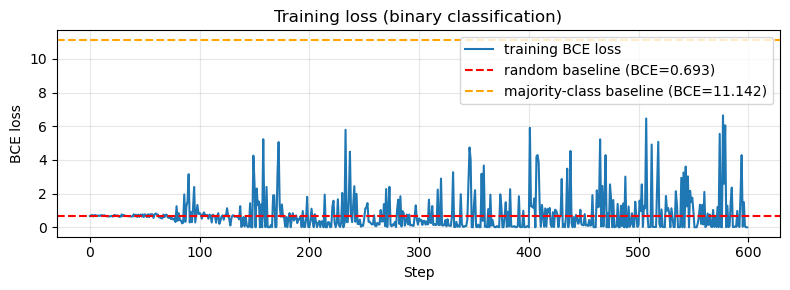

In [10]:
import math

RANDOM_BCE = math.log(2)  # BCE for uniformly random predictions (~0.693)
print(f'Random-guess baseline BCE: {RANDOM_BCE:.4f}')

# Majority-class baseline BCE
all_labels_arr = np.array([dataset[i]['coverage'].numpy() for i in range(len(dataset))])
majority_pos_rate = all_labels_arr.mean(axis=0)  # fraction positive per fate
# BCE for always predicting majority class
def majority_bce(p):
    maj = float(p >= 0.5)
    return -(p * math.log(maj + 1e-12) + (1-p) * math.log(1 - maj + 1e-12))
maj_bce = np.mean([majority_bce(p) for p in majority_pos_rate])
print(f'Majority-class baseline BCE: {maj_bce:.4f}')

# Reinitialise fresh model and optimizer
model2 = FateCoverageNet(
    C_in=n_hks, n_fates=n_fates,
    C_width=C_WIDTH, N_block=N_BLOCK,
    mlp_hidden=MLP_HIDDEN, dropout=DROPOUT,
).to(device)
opt2 = optim.Adam(model2.parameters(), lr=LR)
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=N_STEPS, eta_min=LR*0.5)
loss_fn2 = nn.BCEWithLogitsLoss()

loss_history = []

N_STEPS = 600

model2.train()
for step in range(N_STEPS):
    opt2.zero_grad()

    idx = np.random.randint(0, len(dataset))
    s = dataset[idx]

    logits = model2(
        s['hks'].to(device),
        s['mass'].to(device),
        s['L'].to(device),
        s['evals'].to(device),
        s['evecs'].to(device),
        s['gradX'].to(device),
        s['gradY'].to(device),
    )
    target = s['coverage'].to(device)  # binary {0, 1}
    loss = loss_fn2(logits.squeeze(0), target)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model2.parameters(), GRAD_CLIP)
    opt2.step()
    scheduler2.step()

    loss_history.append(loss.item())
    if (step + 1) % LOG_EVERY == 0 or step == 0:
        print(f'Step {step+1:4d} | BCE = {loss.item():.5f}  '
              f'(random baseline={RANDOM_BCE:.3f}, lr={opt2.param_groups[0]["lr"]:.2e})')

print('Done.')

plt.figure(figsize=(8, 3))
plt.plot(loss_history, label='training BCE loss')
plt.axhline(RANDOM_BCE, color='red',    linestyle='--', label=f'random baseline (BCE={RANDOM_BCE:.3f})')
plt.axhline(maj_bce,    color='orange', linestyle='--', label=f'majority-class baseline (BCE={maj_bce:.3f})')
plt.xlabel('Step'); plt.ylabel('BCE loss'); plt.title('Training loss (binary classification)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 8. Activation / dead-neuron analysis

Key diagnostic: if `dead%` is high (>50%) in early ReLU layers, the HKS
normalisation or learning rate is likely the cause of the encoder collapse.


In [17]:
activations = {}

def make_hook(name):
    def hook(module, inp, out):
        if isinstance(out, torch.Tensor):
            activations[name] = out.detach()
    return hook

hooks = []
for name, module in model2.encoder.named_modules():
    if isinstance(module, (nn.Linear, nn.ReLU)):
        h = module.register_forward_hook(make_hook(f'enc.{name}'))
        hooks.append(h)

model2.eval()
with torch.no_grad():
    _ = model2.encoder(
        hks_t, mass_t, L_t, evals_t, evecs_t, gradX_t, gradY_t)

for h in hooks:
    h.remove()

print(f'Captured {len(activations)} layer activations after {N_STEPS} training steps:\n')
for name, act in list(activations.items())[:20]:
    arr = act.cpu().numpy()
    dead = (arr == 0).mean() * 100
    flag = '  ⚠️ HIGH DEAD' if dead > 70 else ''
    print(f'  {name:<50} shape={str(tuple(arr.shape)):<20} '
          f'mean={arr.mean():.4f}  std={arr.std():.4f}  dead={dead:.1f}%{flag}')

Captured 30 layer activations after 600 training steps:

  enc.first_lin                                      shape=(1, 1283, 32)        mean=0.0226  std=0.2363  dead=0.0%
  enc.block_0.gradient_features.A_re                 shape=(1, 1283, 32)        mean=-0.0033  std=1.4785  dead=0.0%
  enc.block_0.gradient_features.A_im                 shape=(1, 1283, 32)        mean=-0.0155  std=0.4939  dead=0.0%
  enc.block_0.mlp.miniMLP_mlp_layer_000              shape=(1, 1283, 32)        mean=0.3310  std=0.9501  dead=0.0%
  enc.block_0.mlp.miniMLP_mlp_act_000                shape=(1, 1283, 32)        mean=0.5546  std=0.7509  dead=48.7%
  enc.block_0.mlp.miniMLP_mlp_layer_001              shape=(1, 1283, 32)        mean=0.2460  std=1.0045  dead=0.0%
  enc.block_0.mlp.miniMLP_mlp_act_001                shape=(1, 1283, 32)        mean=0.4984  std=0.7787  dead=51.3%
  enc.block_0.mlp.miniMLP_mlp_layer_002              shape=(1, 1283, 32)        mean=0.1932  std=1.0420  dead=0.0%
  enc.block_1.gradi

## 9. Prediction quality after training

Evaluate on a held-out set of organoids not seen during mini-loop training.

Eval on 50 organoids:
  Fate         Accuracy       F1    Maj.Acc  (Accuracy > Maj.Acc = learning)
  lgr            0.8800   0.9032     0.6161  ✓ learning!
  sero           0.7800   0.8070     0.5000  ✓ learning!
  lyz            0.7800   0.8308     0.6742  ✓ learning!


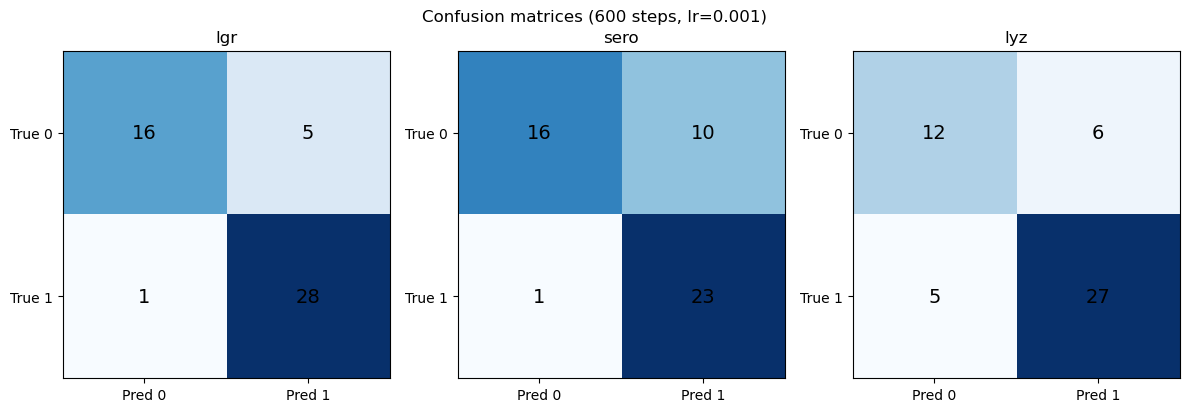

In [11]:
N_EVAL = min(50, len(dataset))
eval_indices = np.random.choice(len(dataset), N_EVAL, replace=False)

model2.eval()
preds, targets = [], []

with torch.no_grad():
    for idx in eval_indices:
        s = dataset[idx]
        logits = model2(
            s['hks'].to(device), s['mass'].to(device),
            s['L'].to(device),   s['evals'].to(device),
            s['evecs'].to(device), s['gradX'].to(device),
            s['gradY'].to(device)
        )
        pred_labels = (torch.sigmoid(logits.squeeze(0)) > 0.5).float()
        preds.append(pred_labels.cpu().numpy())
        targets.append(s['coverage'].numpy())

preds   = np.array(preds)    # (N_EVAL, n_fates) binary
targets = np.array(targets)  # (N_EVAL, n_fates) binary

# Majority-class baseline accuracy per fate
maj_acc = np.maximum(majority_pos_rate, 1.0 - majority_pos_rate)

print(f'Eval on {N_EVAL} organoids:')
print(f"  {'Fate':<10} {'Accuracy':>10} {'F1':>8} {'Maj.Acc':>10}  (Accuracy > Maj.Acc = learning)")
for i, fn in enumerate(FATE_NAMES):
    p  = preds[:, i]
    t  = targets[:, i]
    acc = (p == t).mean()
    tp  = ((p == 1) & (t == 1)).sum()
    fp  = ((p == 1) & (t == 0)).sum()
    fn_ = ((p == 0) & (t == 1)).sum()
    prec = tp / (tp + fp + 1e-12)
    rec  = tp / (tp + fn_ + 1e-12)
    f1   = 2 * prec * rec / (prec + rec + 1e-12)
    flag = '  ✓ learning!' if acc > maj_acc[i] + 0.01 else ''
    print(f'  {fn:<10} {acc:>10.4f} {f1:>8.4f} {maj_acc[i]:>10.4f}{flag}')

# Confusion matrices per fate
fig, axes = plt.subplots(1, len(FATE_NAMES), figsize=(4*len(FATE_NAMES), 4))
if len(FATE_NAMES) == 1:
    axes = [axes]
for ax, fn, i in zip(axes, FATE_NAMES, range(len(FATE_NAMES))):
    p = preds[:, i]; t = targets[:, i]
    cm = np.array([[((p==0)&(t==0)).sum(), ((p==1)&(t==0)).sum()],
                   [((p==0)&(t==1)).sum(), ((p==1)&(t==1)).sum()]])
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0,1]); ax.set_xticklabels(['Pred 0','Pred 1'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['True 0','True 1'])
    for r in range(2):
        for c in range(2):
            ax.text(c, r, str(cm[r, c]), ha='center', va='center', fontsize=14)
    ax.set_title(fn)
plt.suptitle(f'Confusion matrices ({N_STEPS} steps, lr={LR})', fontsize=12)
plt.tight_layout()
plt.show()


## 10. Interpretation guide

**If BCE loss < random baseline (log(2) ≈ 0.693) and accuracy > majority-class baseline:**  
→ DiffusionNet is learning to classify fate presence/absence. The collapse in
the VAE is likely caused by the Chamfer+KL objective rather than the encoder.
Next steps: increase `beta_kl` warmup, normalise HKS per-batch, or try a
smaller learning rate.

**If BCE loss stays near log(2) ≈ 0.693:**  
→ The encoder is not extracting class-discriminative features. Possible causes:
- HKS values too large/small → spectral filters saturate. Try log(hks+1).
- C_width too small → increase to 128 and add more blocks.
- Learning rate too high → try 1e-4.
- Class imbalance → consider `pos_weight` in BCEWithLogitsLoss.

**If dead% is very high (>80%) after training:**  
→ ReLU neurons are dying. Potential fixes:
- Use LeakyReLU or ELU in DiffusionNet MiniMLP.
- Reduce learning rate.
- Add batch normalisation before each ReLU.
- Normalise HKS to zero mean / unit variance per-vertex.
